In [21]:
import torch, gpytorch
from core.utils import *


In [22]:
n_data = 50
gamma = torch.linspace(0.0, 12.0, n_data)
F_ut =  torch.zeros((n_data, 3, 3))

F_ut[:, 0, 0] = 1 + gamma
# F_ut[:, 1, 1] = (1 + gamma)**-0.5 
# F_ut[:, 2, 2] = (1 + gamma)**-0.5
 
F_ut[:, 1, 1] = 1
F_ut[:, 2, 2] = 1
F_ut[:, 0, 1] = 0

F_ut.requires_grad=True
B = B_func(F_ut)
I1 = I1_func(B)
I2 = I2_func(B)
I3 = I3_func(B)

In [23]:
Phi = MooneyRivlinPhi(I1, I2, I3)

Piola = torch.autograd.grad(Phi.clone().sum(), F_ut, retain_graph = True)[0]  # same shape as f [3,3]
tau = Piola @ F_ut.transpose(-2, -1)
sigma = tau / J_func(F_ut)[:, None, None]

In [24]:
torch.mean(sigma, dim = 0)

tensor([[120.1380,   0.0000,   0.0000],
        [  0.0000, 119.8360,   0.0000],
        [  0.0000,   0.0000, 119.8360]], grad_fn=<MeanBackward1>)

In [25]:
noise_percentage = 0.01
noise_level = noise_percentage * sigma
noise = noise_level * torch.normal(torch.zeros_like(sigma), torch.ones_like(sigma))
sigma_noised = sigma + noise

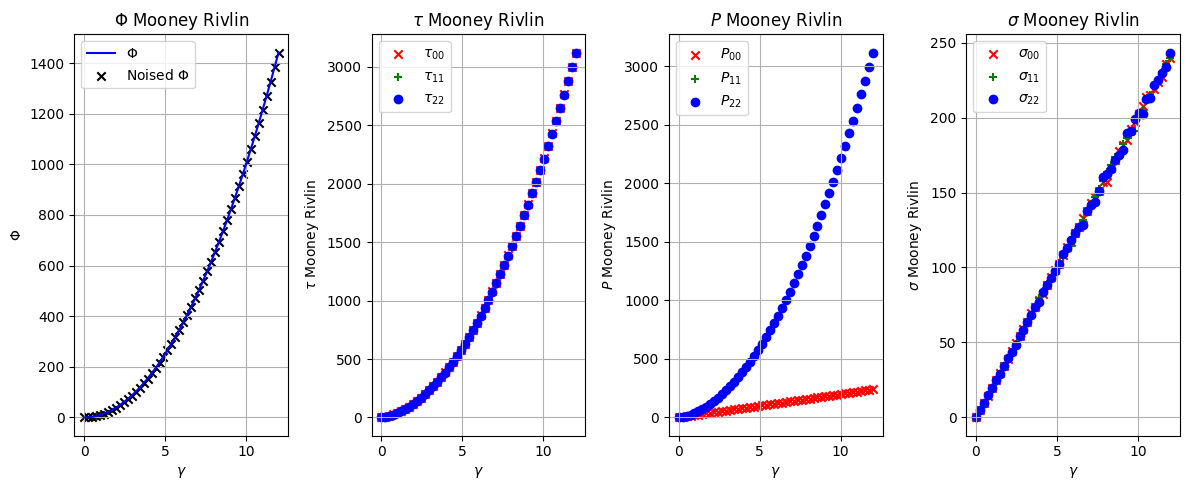

In [26]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 4, figsize=(12, 5))  # 1 row, 2 columns

# First subplot: Phi vs gamma
axs[0].plot(gamma.numpy(), Phi.detach().numpy(), color="b", label=r'$\Phi$')
axs[0].scatter(gamma.numpy(), Phi.detach().numpy(), color="k", marker="x", label=r'Noised $\Phi$')
axs[0].set_xlabel(r'$\gamma$')
axs[0].set_ylabel(r'$\Phi$')
axs[0].set_title(r'$\Phi$ Mooney Rivlin')
axs[0].grid(True)
axs[0].legend()

# Second subplot: tau_noised components vs gamma
axs[1].scatter(gamma.numpy(), tau[:, 0, 0].detach().numpy(), color="r", marker="x", label=r'$\tau_{00}$')
axs[1].scatter(gamma.numpy(), tau[:, 1, 1].detach().numpy(), color="g", marker="+", label=r'$\tau_{11}$')
axs[1].scatter(gamma.numpy(), tau[:, 2, 2].detach().numpy(), color="b", marker="o", label=r'$\tau_{22}$')
axs[1].set_xlabel(r'$\gamma$')
axs[1].set_ylabel(r'$\tau$ Mooney Rivlin')
axs[1].set_title(r'$\tau$ Mooney Rivlin')
axs[1].grid(True)
axs[1].legend()

axs[2].scatter(gamma.numpy(), Piola[:, 0, 0].detach().numpy(), color="r", marker="x", label=r'$P_{00}$')
axs[2].scatter(gamma.numpy(), Piola[:, 1, 1].detach().numpy(), color="g", marker="+", label=r'$P_{11}$')
axs[2].scatter(gamma.numpy(), Piola[:, 2, 2].detach().numpy(), color="b", marker="o", label=r'$P_{22}$')
axs[2].set_xlabel(r'$\gamma$')
axs[2].set_ylabel(r'$P$ Mooney Rivlin')
axs[2].set_title(r'$P$ Mooney Rivlin')
axs[2].grid(True)
axs[2].legend()

axs[3].scatter(gamma.numpy(), sigma_noised[:, 0, 0].detach().numpy(), color="r", marker="x", label=r'$\sigma_{00}$')
axs[3].scatter(gamma.numpy(), sigma_noised[:, 1, 1].detach().numpy(), color="g", marker="+", label=r'$\sigma_{11}$')
axs[3].scatter(gamma.numpy(), sigma_noised[:, 2, 2].detach().numpy(), color="b", marker="o", label=r'$\sigma_{22}$')
axs[3].set_xlabel(r'$\gamma$')
axs[3].set_ylabel(r'$\sigma$ Mooney Rivlin')
axs[3].set_title(r'$\sigma$ Mooney Rivlin')
axs[3].grid(True)
axs[3].legend()

plt.tight_layout()
plt.show()


In [27]:
def to_voigt(tensor_batch):
    """
    Convert a batch of 3x3 symmetric tensors to Voigt notation (6 components).
    
    Input:
        tensor_batch: torch.Tensor of shape (N, 3, 3)
    Output:
        voigt_batch: torch.Tensor of shape (N, 6)
                     Order: [σ11, σ22, σ33, σ12, σ13, σ23]
    """
    N = tensor_batch.shape[0]
    voigt_batch = torch.zeros((N, 6), dtype=tensor_batch.dtype, device=tensor_batch.device)
    
    # Normal components
    voigt_batch[:, 0] = tensor_batch[:, 0, 0]  # σ11
    voigt_batch[:, 1] = tensor_batch[:, 1, 1]  # σ22
    voigt_batch[:, 2] = tensor_batch[:, 2, 2]  # σ33
    
    # Shear components
    voigt_batch[:, 3] = tensor_batch[:, 0, 1]  # σ12
    voigt_batch[:, 4] = tensor_batch[:, 0, 2]  # σ13
    voigt_batch[:, 5] = tensor_batch[:, 1, 2]  # σ23
    
    return voigt_batch


In [28]:
B_train = B_func(F_ut).detach()
train_x = torch.stack([I1_func(B_train), I2_func(B_train), I3_func(B_train)]).T
# train_x = I1_func(B_train)
train_y = to_voigt(sigma_noised).detach()

In [46]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        # self.mean_module = gpytorch.means.ConstantMean()
        self.mean_module = gpytorch.means.LinearMean(3)
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=3))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [47]:
# class MultitaskGPModel(gpytorch.models.ExactGP):
#     def __init__(self, train_x, train_y, likelihood):
#         super(MultitaskGPModel, self).__init__(train_x, train_y, likelihood)
#         self.mean_module = gpytorch.means.MultitaskMean(
#             gpytorch.means.ConstantMean(), num_tasks=6
#         )
#         self.covar_module = gpytorch.kernels.MultitaskKernel(
#             gpytorch.kernels.RBFKernel(ard_num_dims=3), num_tasks=6, rank=1
#         )

#     def forward(self, x):
#         mean_x = self.mean_module(x)
#         covar_x = self.covar_module(x)
#         return gpytorch.distributions.MultitaskMultivariateNormal(mean_x, covar_x)


# likelihood = gpytorch.likelihoods.MultitaskGaussianLikelihood(num_tasks=6)
# model = ExactGPModel(train_x, train_y, likelihood)
likelihood1, likelihood2, likelihood3, likelihood4, likelihood5, likelihood6 = gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood()
model1 = ExactGPModel(train_x, train_y[:, 0], likelihood1)
model2 = ExactGPModel(train_x, train_y[:, 1], likelihood2)
model3 = ExactGPModel(train_x, train_y[:, 2], likelihood3)
model4 = ExactGPModel(train_x, train_y[:, 3], likelihood4)
model5 = ExactGPModel(train_x, train_y[:, 4], likelihood5)
model6 = ExactGPModel(train_x, train_y[:, 5], likelihood6)

In [48]:
from gpytorch.mlls import SumMarginalLogLikelihood
model = gpytorch.models.IndependentModelList(model1, model2, model3, model4, model5, model6)
likelihood = gpytorch.likelihoods.LikelihoodList(model1.likelihood, model2.likelihood, model3.likelihood, model4.likelihood, model5.likelihood, model6.likelihood)
mll = SumMarginalLogLikelihood(likelihood, model)

In [219]:
training_iter = 5000
model.train()
likelihood.train()

from torch.optim.lr_scheduler import ReduceLROnPlateau

# Use a realistic learning rate for Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)  

# Scheduler reduces lr by factor 0.5 after 20 epochs of no improvement
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

for i in range(training_iter):
    optimizer.zero_grad()
    output = model(*model.train_inputs)
    loss = -mll(output, model.train_targets)
    loss.backward()

    optimizer.step()
    scheduler.step(loss)

    if i % 50 == 0 or i == training_iter - 1:
        print(f"Iter {i+1}/{training_iter} - Loss: {loss.item():.6f} - lr: {optimizer.param_groups[0]['lr']:.2e}")


Iter 1/5000 - Loss: 2.424940 - lr: 5.00e-02
Iter 51/5000 - Loss: 2.412543 - lr: 5.00e-02
Iter 101/5000 - Loss: 2.401099 - lr: 5.00e-02
Iter 151/5000 - Loss: 2.390658 - lr: 5.00e-02
Iter 201/5000 - Loss: 2.381014 - lr: 5.00e-02
Iter 251/5000 - Loss: 2.372096 - lr: 5.00e-02
Iter 301/5000 - Loss: 2.363837 - lr: 5.00e-02
Iter 351/5000 - Loss: 2.356133 - lr: 5.00e-02
Iter 401/5000 - Loss: 2.348905 - lr: 5.00e-02
Iter 451/5000 - Loss: 2.342041 - lr: 5.00e-02
Iter 501/5000 - Loss: 2.335586 - lr: 5.00e-02
Iter 551/5000 - Loss: 2.329341 - lr: 5.00e-02
Iter 601/5000 - Loss: 2.323422 - lr: 5.00e-02
Iter 651/5000 - Loss: 2.317697 - lr: 5.00e-02
Iter 701/5000 - Loss: 2.312212 - lr: 5.00e-02
Iter 751/5000 - Loss: 2.306920 - lr: 5.00e-02
Iter 801/5000 - Loss: 2.301845 - lr: 5.00e-02
Iter 851/5000 - Loss: 2.296907 - lr: 5.00e-02
Iter 901/5000 - Loss: 2.292141 - lr: 5.00e-02
Iter 951/5000 - Loss: 2.287514 - lr: 5.00e-02
Iter 1001/5000 - Loss: 2.283025 - lr: 5.00e-02
Iter 1051/5000 - Loss: 2.278668 - lr

<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_90717/3117454745.py:43: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel("$\gamma$")


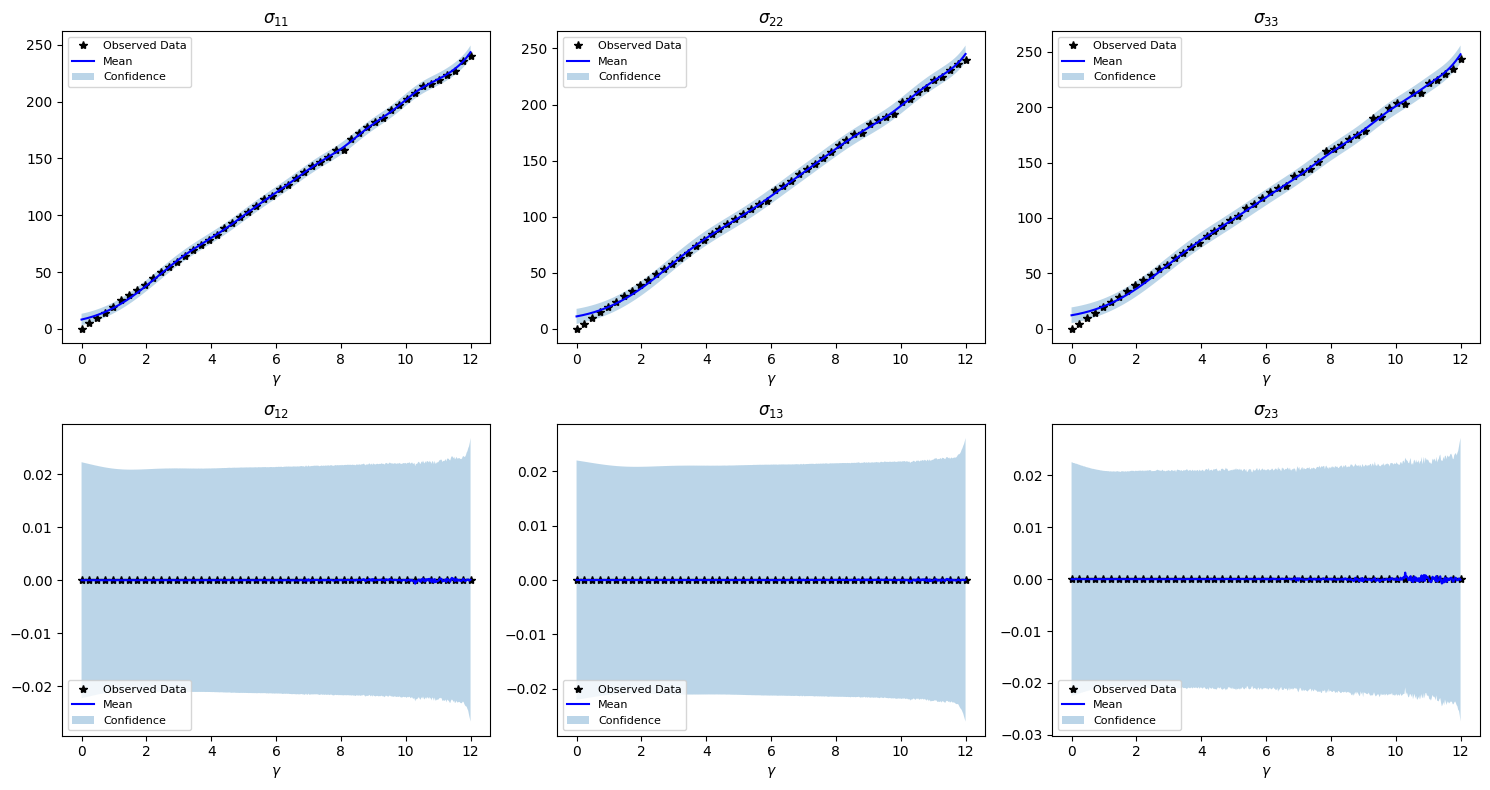

In [51]:
model.eval()
likelihood.eval()

n_data = 500
gamma_test = torch.linspace(0.0, 12.0, n_data)
F_ut_test =  torch.zeros((n_data, 3, 3))

F_ut_test[:, 0, 0] = 1 + gamma_test
F_ut_test[:, 1, 1] = 1
F_ut_test[:, 2, 2] = 1
# Make predictionsimport matplotlib.pyplot as plt

# Number of tasks (stress components)
num_tasks = 6

# Create 2×3 subplot grid
fig, axs = plt.subplots(2, 3, figsize=(15, 8))  # wider and taller for readability
axs = axs.flatten()  # flatten to 1D list for easy iteration

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    B_test = B_func(F_ut_test).detach()
    test_x = torch.stack([I1_func(B_test), I2_func(B_test), I3_func(B_test)]).T
    predictions = likelihood(*model(test_x, test_x, test_x, test_x, test_x, test_x))

stress_labels = [r"$\sigma_{11}$", r"$\sigma_{22}$", r"$\sigma_{33}$", r"$\sigma_{12}$", r"$\sigma_{13}$", r"$\sigma_{23}$"]
# Loop through tasks
for i, (submodel, prediction, ax) in enumerate(zip(model.models, predictions, axs)):
    mean = prediction.mean
    lower, upper = prediction.confidence_region()

    tr_x = submodel.train_inputs[0].detach().numpy()
    tr_y = submodel.train_targets.detach().numpy()

    ax.plot(gamma.numpy(), tr_y, 'k*', label='Observed Data')
    ax.plot(gamma_test.numpy(), mean.numpy(), 'b', label='Mean')
    ax.fill_between(gamma_test.numpy(),
                    lower.detach().numpy(),
                    upper.detach().numpy(),
                    alpha=0.3, label='Confidence')

    # ax.set_xlim([8, 8.5])
    ax.set_title(f'{stress_labels[i]}')
    ax.set_xlabel("$\gamma$")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [348]:
test_x = [torch.stack([I1_func(B_test), I2_func(B_test), I3_func(B_test)]).T] * 6

In [52]:
import torch

In [57]:
a = torch.tensor([[1, 2, 4],
              [1, 1, 1],
              [1, 1, 1]], dtype = torch.float64)

In [58]:
torch.svd(a)

torch.return_types.svd(
U=tensor([[-8.9551e-01,  4.4504e-01, -8.7561e-17],
        [-3.1469e-01, -6.3322e-01, -7.0711e-01],
        [-3.1469e-01, -6.3322e-01,  7.0711e-01]], dtype=torch.float64),
S=tensor([5.0911, 1.0394, 0.0000], dtype=torch.float64),
V=tensor([[-0.2995, -0.7903,  0.5345],
        [-0.4754, -0.3621, -0.8018],
        [-0.8272,  0.4943,  0.2673]], dtype=torch.float64))

In [180]:
import torch

n_data = 100
gamma = torch.linspace(0.0, 12.0, n_data)
F_ut =  torch.zeros((n_data, 3, 3))

F_ut[:, 0, 0] = 1 + gamma
# F_ut[:, 1, 1] = (1 + gamma)**-0.5 
# F_ut[:, 2, 2] = (1 + gamma)**-0.5
 
F_ut[:, 1, 1] = 1
F_ut[:, 2, 2] = 1
F_ut[:, 0, 1] = gamma * 0.0
F_ut.requires_grad=True
B_train = B_func(F_ut)
I1 = I1_func(B_train)
I2 = I2_func(B_train)
I3 = I3_func(B_train)
Phi = MooneyRivlinPhi(I1, I2, I3)
rel_noise_level = 0.05
noise_level =  rel_noise_level * Phi
noise = torch.normal(torch.zeros_like(Phi), torch.ones_like(Phi)) * noise_level
Phi_noised = Phi + noise

Piola_noised = torch.autograd.grad(Phi_noised.clone().sum(), F_ut, retain_graph = False)[0]  # same shape as f [3,3]
tau_noised = Piola_noised @ F_ut.transpose(-2, -1)
sigma_noised = (tau_noised / J_func(F_ut)[:, None, None]).detach()

def solve_for_coefficients(lambda_B, lambda_sigma):
    """
    Solves the linear system V * c = lambda_sigma for the coefficients c.
    V is the Vandermonde matrix formed by the stretch eigenvalues.
    
    Vandermonde Matrix:
        | 1  lambda_1  lambda_1^2 |
    V = | 1  lambda_2  lambda_2^2 |
        | 1  lambda_3  lambda_3^2 |
    """
    
    # Check if the inputs are 1D tensors of size 3
    if lambda_B.shape != (3,) or lambda_sigma.shape != (3,):
        raise ValueError("Input eigenvalues must be 1D tensors of size 3.")

    # --- 2. Form the Vandermonde Matrix (V) ---
    # Col 1: [1, 1, 1]
    col1 = torch.ones_like(lambda_B)
    # Col 2: [lambda_1, lambda_2, lambda_3]
    col2 = lambda_B
    # Col 3: [lambda_1^2, lambda_2^2, lambda_3^2]
    col3 = lambda_B**2
    
    # Stack columns to form the 3x3 Vandermonde matrix V
    V = torch.stack((col1, col2, col3), dim=1)
    
    # --- 3. Solve for c using the Pseudoinverse (SVD) ---
    # torch.linalg.pinv computes the Moore-Penrose pseudoinverse using SVD,
    # which is robust to singular (rank-deficient) matrices.
    V_pinv = torch.linalg.pinv(V)
    
    # Solve for c: c = V_pinv @ lambda_sigma
    coefficients_c = V_pinv @ lambda_sigma
    
    return coefficients_c, V

# --- Solve Examples ---


In [181]:
sigma_noised.shape

torch.Size([100, 3, 3])

In [182]:
sigma_eig_val, sigma_eig_vec = torch.linalg.eig(sigma_noised)
B_eig_val, B_eig_vec = torch.linalg.eig(B_train)
B_eig_val = B_eig_val.to(dtype = torch.float64)
sigma_eig_val = sigma_eig_val.to(dtype = torch.float64)

In [183]:
import torch

def solve_for_coefficients_batched(lambda_B, lambda_sigma):
    """
    Batched version of solve_for_coefficients.

    Args:
        lambda_B: Tensor of shape (batch_size, 3)
        lambda_sigma: Tensor of shape (batch_size, 3)

    Returns:
        coefficients_c: Tensor of shape (batch_size, 3)
        V: Vandermonde matrices of shape (batch_size, 3, 3)
    """

    # --- 1. Validate input shapes ---
    if lambda_B.ndim != 2 or lambda_B.shape[1] != 3:
        raise ValueError("lambda_B must have shape (batch_size, 3)")
    if lambda_sigma.ndim != 2 or lambda_sigma.shape[1] != 3:
        raise ValueError("lambda_sigma must have shape (batch_size, 3)")
    if lambda_B.shape[0] != lambda_sigma.shape[0]:
        raise ValueError("Batch sizes of lambda_B and lambda_sigma must match.")

    # --- 2. Construct Vandermonde matrices ---
    # V[i] = [[1, λ1, λ1²],
    #         [1, λ2, λ2²],
    #         [1, λ3, λ3²]]
    col1 = torch.ones_like(lambda_B)
    col2 = lambda_B
    col3 = lambda_B**2

    V = torch.stack((col1, col2, col3), dim=-1)  # (batch_size, 3, 3)

    # --- 3. Compute pseudoinverses for each batch ---
    # torch.linalg.pinv supports batched input
    V_pinv = torch.linalg.pinv(V)  # (batch_size, 3, 3)

    # --- 4. Solve for c ---
    # (batch_size, 3, 3) @ (batch_size, 3, 1) -> (batch_size, 3, 1)
    coefficients_c = torch.bmm(V_pinv, lambda_sigma.unsqueeze(-1)).squeeze(-1)

    return coefficients_c, V


In [184]:
coeffs, _ = solve_for_coefficients_batched(B_eig_val, sigma_eig_val)

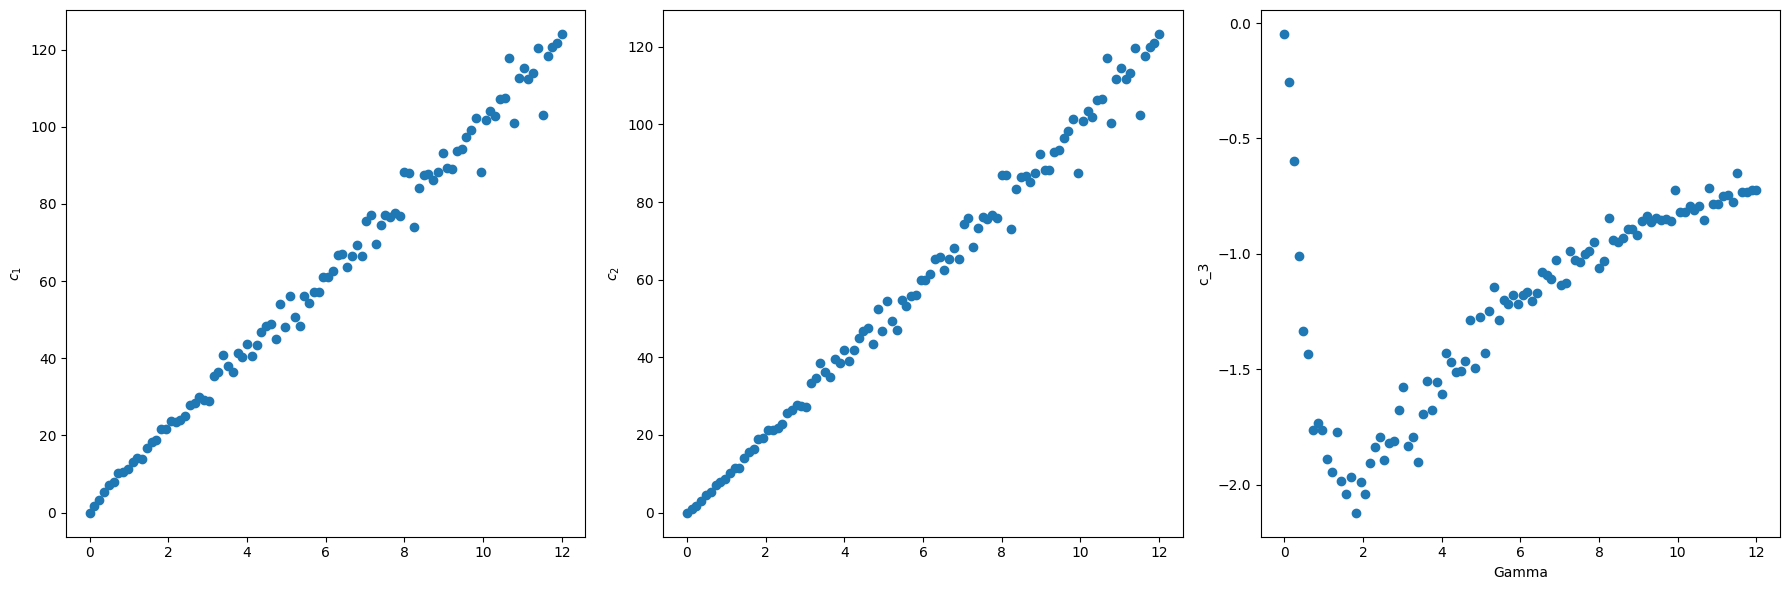

In [207]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

axes[0].scatter(gamma.detach(), coeffs[:, 0].detach())
axes[0].set_ylabel('$c_1$')

axes[1].scatter(gamma.detach(), coeffs[:, 1].detach())
axes[1].set_ylabel('$c_2$')

axes[2].scatter(gamma.detach(), coeffs[:, 2].detach())
axes[2].set_ylabel('c_3')
axes[2].set_xlabel('Gamma')

plt.tight_layout()
plt.show()


In [188]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super().__init__(train_x, train_y, likelihood)
        # self.mean_module = gpytorch.means.ConstantMean()
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel(ard_num_dims=3))

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

In [195]:
train_x = torch.stack([I1_func(B_train), I2_func(B_train), I3_func(B_train)]).T.detach()
train_y = coeffs.detach()

In [196]:
likelihood1, likelihood2, likelihood3 = gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood(), gpytorch.likelihoods.GaussianLikelihood()
model1 = ExactGPModel(train_x, train_y[:, 0], likelihood1)
model2 = ExactGPModel(train_x, train_y[:, 1], likelihood2)
model3 = ExactGPModel(train_x, train_y[:, 2], likelihood3)

In [197]:
from gpytorch.mlls import SumMarginalLogLikelihood
model = gpytorch.models.IndependentModelList(model1, model2, model3)
likelihood = gpytorch.likelihoods.LikelihoodList(model1.likelihood, model2.likelihood, model3.likelihood)
mll = SumMarginalLogLikelihood(likelihood, model)

In [217]:
training_iter = 5000
model.train()
likelihood.train()

from torch.optim.lr_scheduler import ReduceLROnPlateau

# Use a realistic learning rate for Adam
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)  

# Scheduler reduces lr by factor 0.5 after 20 epochs of no improvement
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

for i in range(training_iter):
    optimizer.zero_grad()
    output = model(*model.train_inputs)
    loss = -mll(output, model.train_targets)
    loss.backward()

    optimizer.step()
    scheduler.step(loss)

    if i % 50 == 0 or i == training_iter - 1:
        print(f"Iter {i+1}/{training_iter} - Loss: {loss.item():.6f} - lr: {optimizer.param_groups[0]['lr']:.2e}")


Iter 1/5000 - Loss: 7.462719 - lr: 5.00e-02
Iter 51/5000 - Loss: 6.564623 - lr: 5.00e-02
Iter 101/5000 - Loss: 5.965923 - lr: 5.00e-02
Iter 151/5000 - Loss: 5.534410 - lr: 5.00e-02
Iter 201/5000 - Loss: 5.204467 - lr: 5.00e-02
Iter 251/5000 - Loss: 4.941901 - lr: 5.00e-02
Iter 301/5000 - Loss: 4.726937 - lr: 5.00e-02
Iter 351/5000 - Loss: 4.546828 - lr: 5.00e-02
Iter 401/5000 - Loss: 4.393364 - lr: 5.00e-02
Iter 451/5000 - Loss: 4.260721 - lr: 5.00e-02
Iter 501/5000 - Loss: 4.144528 - lr: 5.00e-02
Iter 551/5000 - Loss: 4.041798 - lr: 5.00e-02
Iter 601/5000 - Loss: 3.950045 - lr: 5.00e-02
Iter 651/5000 - Loss: 3.867564 - lr: 5.00e-02
Iter 701/5000 - Loss: 3.792762 - lr: 5.00e-02
Iter 751/5000 - Loss: 3.724699 - lr: 5.00e-02
Iter 801/5000 - Loss: 3.662363 - lr: 5.00e-02
Iter 851/5000 - Loss: 3.604954 - lr: 5.00e-02
Iter 901/5000 - Loss: 3.551758 - lr: 5.00e-02
Iter 951/5000 - Loss: 3.502597 - lr: 5.00e-02
Iter 1001/5000 - Loss: 3.456668 - lr: 5.00e-02
Iter 1051/5000 - Loss: 3.413842 - lr

<>:43: SyntaxWarning: invalid escape sequence '\g'
<>:43: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_90717/400208216.py:43: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel("$\gamma$")
/dolfinx-env/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/tmp/ipykernel_90717/400208216.py:43: SyntaxWarning: invalid escape sequence '\g'
  ax.set_xlabel("$\gamma$")


RuntimeError: Expected b and A to have the same dtype, but found b of type Double and A of type Float instead.

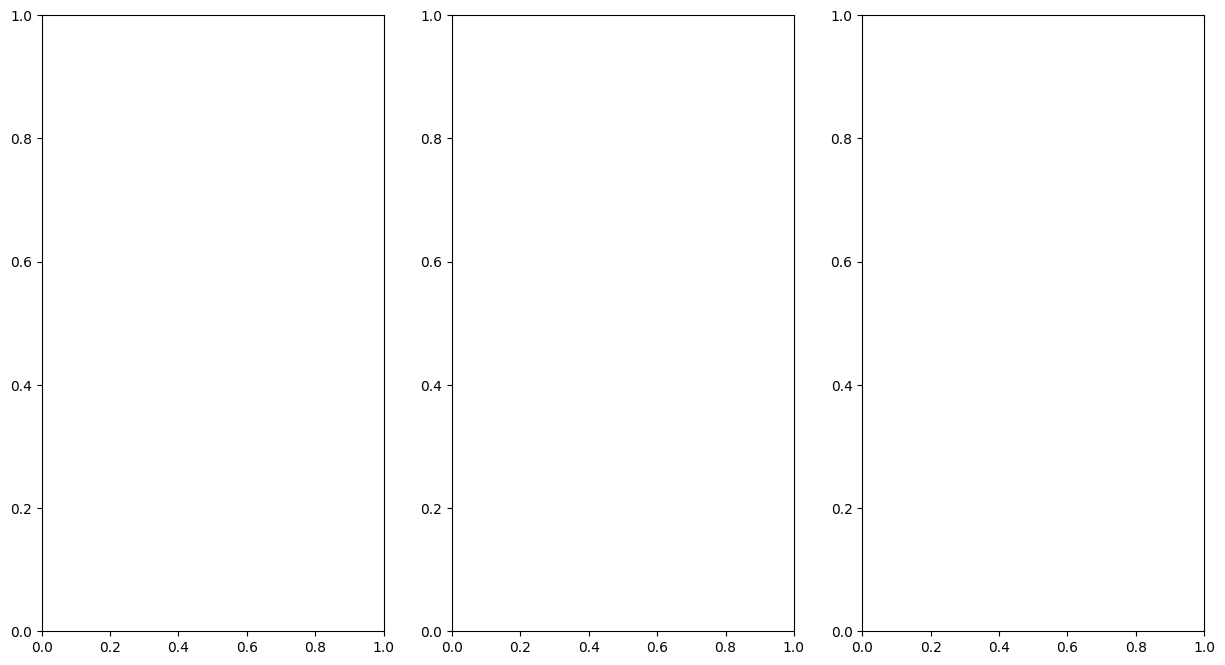

In [218]:
model.eval()
likelihood.eval()

n_data = 500
gamma_test = torch.linspace(0.0, 12.0, n_data).to(dtype = torch.float64)
F_ut_test =  torch.zeros((n_data, 3, 3), dtype = torch.float64)

F_ut_test[:, 0, 0] = 1 + gamma_test
F_ut_test[:, 1, 1] = 1
F_ut_test[:, 2, 2] = 1
# Make predictionsimport matplotlib.pyplot as plt

# Number of tasks (stress components)
num_tasks = 3

# Create 2×3 subplot grid
fig, axs = plt.subplots(1, 3, figsize=(15, 8))  # wider and taller for readability
axs = axs.flatten()  # flatten to 1D list for easy iteration

with torch.no_grad(), gpytorch.settings.fast_pred_var():
    B_test = B_func(F_ut_test).detach()
    test_x = torch.stack([I1_func(B_test), I2_func(B_test), I3_func(B_test)]).T
    predictions = likelihood(*model(train_x, train_x, train_x))

stress_labels = [r"$\c_{1}$", r"$\c_{2}$", r"$\c_{3}$"]
# Loop through tasks
for i, (submodel, prediction, ax) in enumerate(zip(model.models, predictions, axs)):
    mean = prediction.mean
    lower, upper = prediction.confidence_region()

    tr_x = submodel.train_inputs[0].detach().numpy()
    tr_y = submodel.train_targets.detach().numpy()

    ax.plot(gamma.numpy(), tr_y, 'k*', label='Observed Data')
    ax.plot(gamma_test.numpy(), mean.numpy(), 'b', label='Mean')
    ax.fill_between(gamma_test.numpy(),
                    lower.detach().numpy(),
                    upper.detach().numpy(),
                    alpha=0.3, label='Confidence')

    # ax.set_xlim([8, 8.5])
    ax.set_title(f'{stress_labels[i]}')
    ax.set_xlabel("$\gamma$")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


In [215]:
F_ut_test

tensor([[[ 1.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.0240,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[ 1.0481,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        ...,

        [[12.9519,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[12.9760,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]],

        [[13.0000,  0.0000,  0.0000],
         [ 0.0000,  1.0000,  0.0000],
         [ 0.0000,  0.0000,  1.0000]]], dtype=torch.float64)